# 07 — Explainability with SHAP

**Inputs:**
- `data/processed/X_features.csv`   (39 × 37)
- `models/best_model.pkl`           (Decision Tree, fitted)
- `models/scaler.pkl`               (fitted StandardScaler)

**What this notebook does:**
1. Loads the fitted model and scaler
2. Runs SHAP TreeExplainer on the model
3. Produces:
   - Global feature importance (bar plot)
   - SHAP summary (beeswarm plot)
   - Local explanations for individual students (waterfall plots)
4. Saves all plots to `figures/` for the thesis

**Important limitation:**
With n=39 and p=37, SHAP values are UNSTABLE. Feature rankings
should be interpreted as preliminary hypotheses, not conclusions.
The same pipeline with 300+ samples will produce reliable rankings.

**Why SHAP?**
Standard feature importance (from sklearn) can be biased toward
high-cardinality features. SHAP gives a game-theoretic, theoretically
sound attribution of each feature's contribution to each prediction.

In [1]:
# Step 1: Load model, scaler, and features.

import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt

# Load features
X = pd.read_csv("../data/processed/X_features.csv")

# Load fitted scaler and model
scaler = joblib.load("../models/scaler.pkl")
model  = joblib.load("../models/best_model.pkl")

# Scale features (fit on train was done in notebook 05; we transform all)
X_scaled = scaler.transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("Loaded:", model.__class__.__name__)
print("Features shape:", X_scaled_df.shape)
print()
print("SHAP version:", shap.__version__)

Loaded: DecisionTreeClassifier
Features shape: (39, 37)

SHAP version: 0.52.0


## Step 2 — Compute SHAP Values

`TreeExplainer` is the SHAP algorithm designed specifically for tree-based
models (Decision Tree, Random Forest, XGBoost). It computes exact SHAP
values in polynomial time — no sampling needed.

SHAP values answer: **how much did each feature contribute to this
prediction, compared to a baseline?**

- Positive SHAP value → feature pushed prediction **toward** that class
- Negative SHAP value → feature pushed prediction **away** from that class
- Magnitude → strength of the contribution

Since our task is 3-class classification, SHAP produces one value per
feature per class per sample — a 3D structure (samples × features × classes).

In [2]:
# Step 2: Build SHAP explainer and compute values.

# TreeExplainer gives exact values for tree-based models
explainer = shap.TreeExplainer(model)

# Compute SHAP values on the scaled feature matrix
shap_values = explainer.shap_values(X_scaled_df)

# In shap 0.4x+, for multi-class we may get either:
#   - a list of arrays (one per class)
#   - or a single 3D array
# We normalize the access here:
if isinstance(shap_values, list):
    # list of arrays, one per class
    print("Got list of arrays (one per class)")
    print("Classes:", model.classes_)
    print("Shapes:", [sv.shape for sv in shap_values])
elif shap_values.ndim == 3:
    print("Got 3D array")
    print("Shape:", shap_values.shape)
    # Convert to list format for consistent handling
    shap_values = [shap_values[:, :, i] for i in range(shap_values.shape[2])]
    print("Converted to list of", len(shap_values), "arrays")
else:
    print("Got 2D array (binary-like)")
    print("Shape:", shap_values.shape)

# Base value(s)
print()
print("Base value(s):")
print(explainer.expected_value)

Got 3D array
Shape: (39, 37, 3)
Converted to list of 3 arrays

Base value(s):
[0.29032258 0.38709677 0.32258065]


## Step 3 — Global Feature Importance

We aggregate SHAP values across all samples and classes:

    importance(feature) = mean over all samples and classes of |SHAP value|

This gives a single "importance" score per feature. It answers:
**which features have the largest impact on predictions overall?**

The top-N features are plotted as a horizontal bar chart.

**Caveat:** With n=39 and p=37, these rankings are unstable. A
different random seed or a slightly different sample would likely
produce different top features. Treat as preliminary hypotheses.

Top 15 most important features (mean |SHAP|):
academic_life_satisfaction            0.1641
social_support                        0.1452
gender_Male                           0.1203
academic_performance                  0.1069
cgpa                                  0.0576
university_Sudurpaschim University    0.0366
physical_activity                     0.0322
year                                  0.0000
age                                   0.0000
attendance                            0.0000
study_hours                           0.0000
assignment_stress                     0.0000
social_media                          0.0000
financial_stress                      0.0000
screen_time                           0.0000

Bottom 5 least important features:
program_BSc CSIT       0.0
program_BSc Nursing    0.0
program_Law(LLB)       0.0
program_MBBS           0.0
part_time_job_Yes      0.0

Saved: ../figures/shap_importance.png


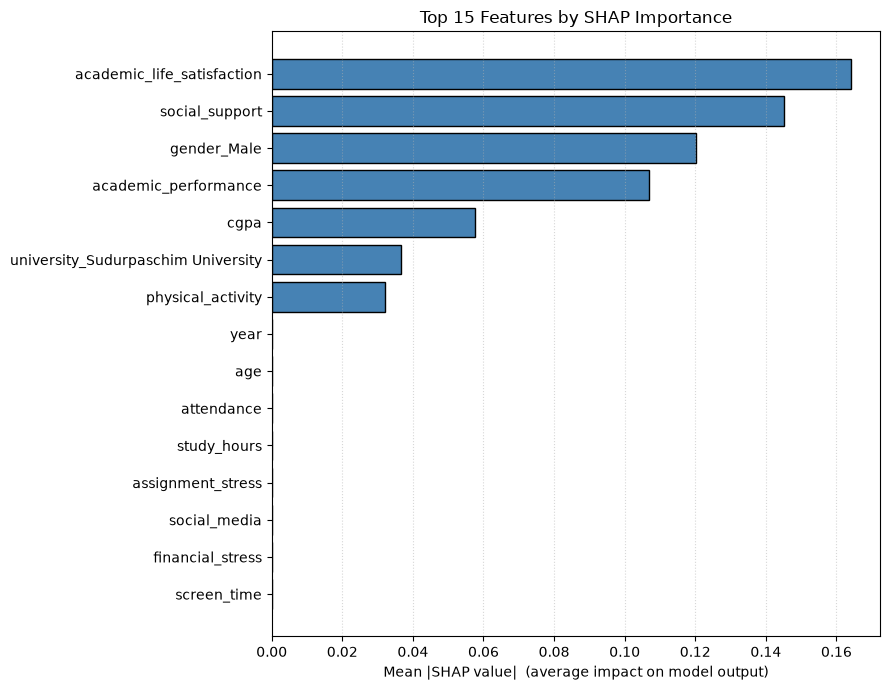

In [3]:
# Step 3: Compute global feature importance (mean absolute SHAP value).

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# shap_values is a list of 3 arrays, each (39, 37)
# Average |SHAP| across classes, then across samples
mean_abs_shap = np.mean([np.abs(sv) for sv in shap_values], axis=0)  # (39, 37)
global_importance = mean_abs_shap.mean(axis=0)                       # (37,)

# Build a Series indexed by feature name, sorted descending
importance_series = pd.Series(global_importance, index=X.columns).sort_values(ascending=False)

print("Top 15 most important features (mean |SHAP|):")
print(importance_series.head(15).round(4).to_string())
print()
print("Bottom 5 least important features:")
print(importance_series.tail(5).round(4).to_string())

# ---- Plot top 15 ----
top_n = 15
top = importance_series.head(top_n).iloc[::-1]  # reverse for horizontal bar

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top.index, top.values, color="steelblue", edgecolor="black")
ax.set_xlabel("Mean |SHAP value|  (average impact on model output)")
ax.set_title(f"Top {top_n} Features by SHAP Importance")
ax.grid(axis="x", linestyle=":", alpha=0.5)

plt.tight_layout()
os.makedirs("../figures", exist_ok=True)
plt.savefig("../figures/shap_importance.png", dpi=150, bbox_inches="tight")
print("\nSaved: ../figures/shap_importance.png")

plt.show()

In [5]:
# Quick check: how many students have each rare feature?

# Check the suspicious university
print("Students at Sudurpaschim University:", X["university_Sudurpaschim University"].sum())
print()

# Check all one-hot columns — how many 1s per feature?
one_hot_cols = [c for c in X.columns if "_" in c and X[c].dropna().isin([0,1]).all() and X[c].nunique() <= 2]
print("One-hot column counts (sorted):")
counts = X[one_hot_cols].sum().sort_values(ascending=False)
print(counts.to_string())

Students at Sudurpaschim University: 6

One-hot column counts (sorted):
part_time_job_Yes                       19
gender_Male                             16
university_Tribhuvan University         16
program_BCA                              8
program_BSc CSIT                         6
university_Sudurpaschim University       6
university_Rajarshi Janak University     5
gender_Prefer not to say                 4
program_MBBS                             4
program_BSc Nursing                      4
program_BDS                              4
university_Purbanchal University         3
university_Pokhara University            3
university_Kathmandu University          2
university_Other                         2
program_BBS                              2
program_BE/B.Tech                        2
program_BHM                              2
program_Law(LLB)                         2
program_BIM                              1


## Step 5 — SHAP Beeswarm Summary

The beeswarm plot shows, for the top features:

- **x-axis**: SHAP value (impact on the model output)
- **y-axis**: features, ranked by importance
- **color**: the actual feature value for each sample
  (red = high, blue = low)
- **each dot**: one student

We produce one plot per class (High / Low / Moderate) to see which
features push predictions toward each stress level, and how their
values relate to that push.

**Note:** With n=39, each dot is one student. Patterns should be read
as suggestive, not conclusive.

Plotting class: High (index 0)
  Saved: ../figures/shap_beeswarm_high.png


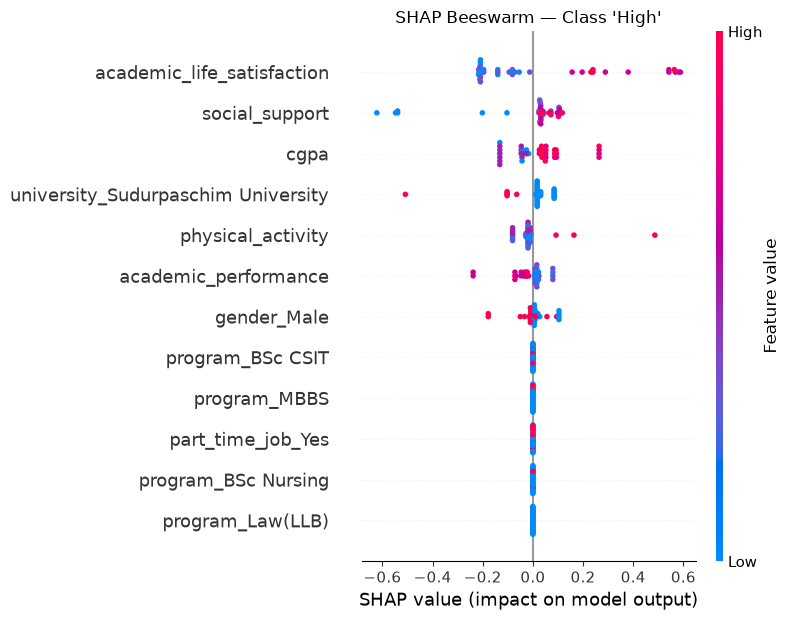

Plotting class: Low (index 1)
  Saved: ../figures/shap_beeswarm_low.png


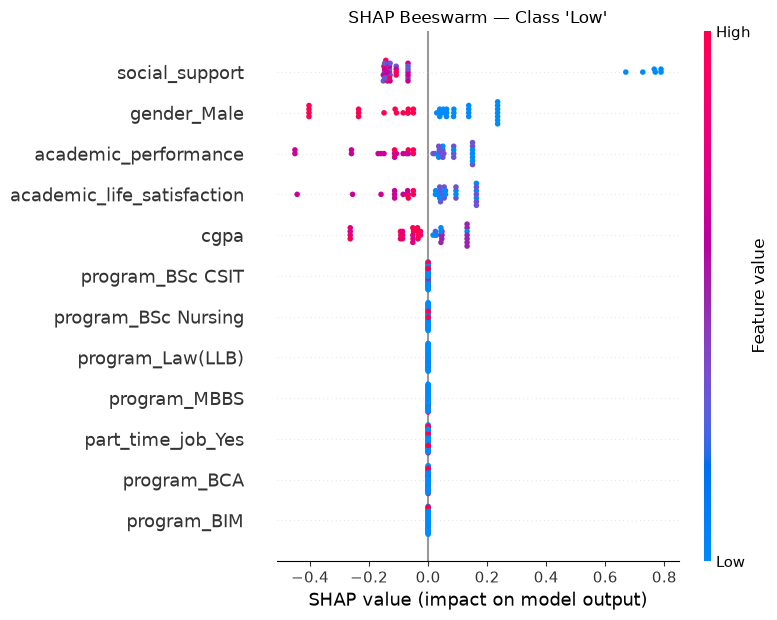

Plotting class: Moderate (index 2)
  Saved: ../figures/shap_beeswarm_moderate.png


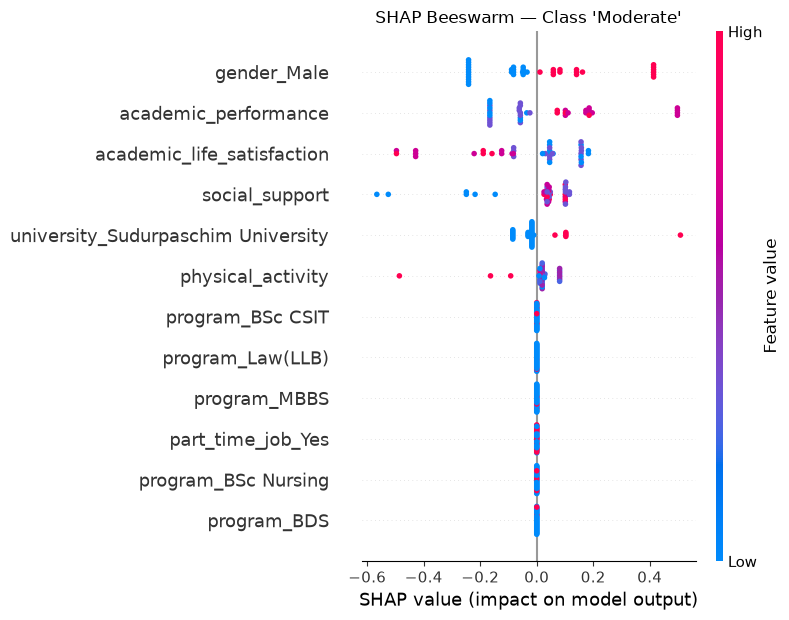

In [6]:
# Step 5: SHAP beeswarm plots — one per class.

import os
import matplotlib.pyplot as plt

os.makedirs("../figures", exist_ok=True)

class_names = list(model.classes_)   # e.g., ['High', 'Low', 'Moderate']

for i, cls in enumerate(class_names):
    print(f"Plotting class: {cls} (index {i})")

    plt.figure(figsize=(10, 7))
    shap.summary_plot(
        shap_values[i],
        X_scaled_df,
        plot_type="dot",
        max_display=12,
        show=False,
    )
    plt.title(f"SHAP Beeswarm — Class '{cls}'", fontsize=12)
    plt.tight_layout()
    path = f"../figures/shap_beeswarm_{cls.lower()}.png"
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print(f"  Saved: {path}")
    plt.show()
    plt.close()

## Step 6 — Local Explanations (Individual Students)

Beeswarm plots show global patterns. For local explanations, we pick
individual students and show the SHAP contributions that drove their
specific prediction.

We choose:
1. A student the model got **right** (to see why the model succeeded)
2. A student the model got **wrong** (to understand failure modes)

Local plots help build intuition for the model's decision process.

In [7]:
# Step 6: Local SHAP explanations for selected students.

# We need scaled test data with class labels for context
from sklearn.model_selection import train_test_split

# Recreate split to get test set
X_raw = pd.read_csv("../data/processed/X_features.csv")
y_raw = pd.read_csv("../data/processed/y_target.csv").squeeze("columns")

X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.20, stratify=y_raw, random_state=42
)

X_test_scaled_df = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

# Predictions on test set
y_pred_test = model.predict(X_test_scaled_df.values)

# Find one correct and one wrong prediction
correct_idx = None
wrong_idx   = None
for i in range(len(y_test)):
    if y_pred_test[i] == y_test.iloc[i] and correct_idx is None:
        correct_idx = i
    if y_pred_test[i] != y_test.iloc[i] and wrong_idx is None:
        wrong_idx = i
    if correct_idx is not None and wrong_idx is not None:
        break

print(f"Correct prediction at test index {correct_idx}:")
print(f"  True: {y_test.iloc[correct_idx]}, Predicted: {y_pred_test[correct_idx]}")
print()
print(f"Wrong prediction at test index {wrong_idx}:")
print(f"  True: {y_test.iloc[wrong_idx]}, Predicted: {y_pred_test[wrong_idx]}")

Correct prediction at test index 2:
  True: High, Predicted: High

Wrong prediction at test index 0:
  True: Low, Predicted: Moderate


## Step 6b — Local Waterfall Plots for Two Students

For each selected student, the waterfall plot shows:

- **Base value** (E[f(X)]): the average prediction
- **Individual contributions**: how each feature pushed the prediction
- **Final prediction**: base + sum of contributions

We pick:
- **Student 2** — the model was correct (High stress, predicted High)
- **Student 0** — the model was wrong (truly Low, predicted Moderate)

Comparing these two explanations reveals why the model succeeded or failed.

Student at test index 2: True=High, Pred=High
Saved: ../figures/shap_waterfall_student_2.png


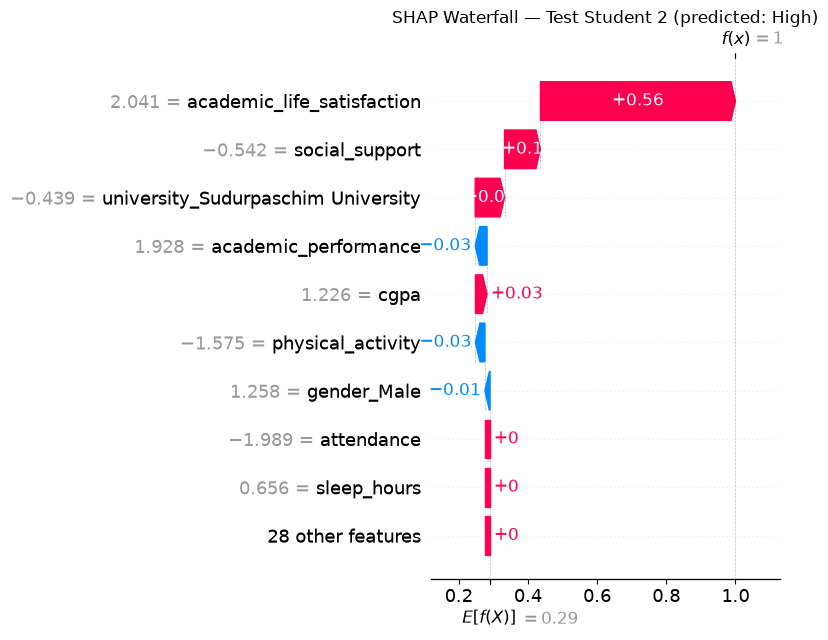


Student at test index 0: True=Low, Pred=Moderate
Saved: ../figures/shap_waterfall_student_0.png


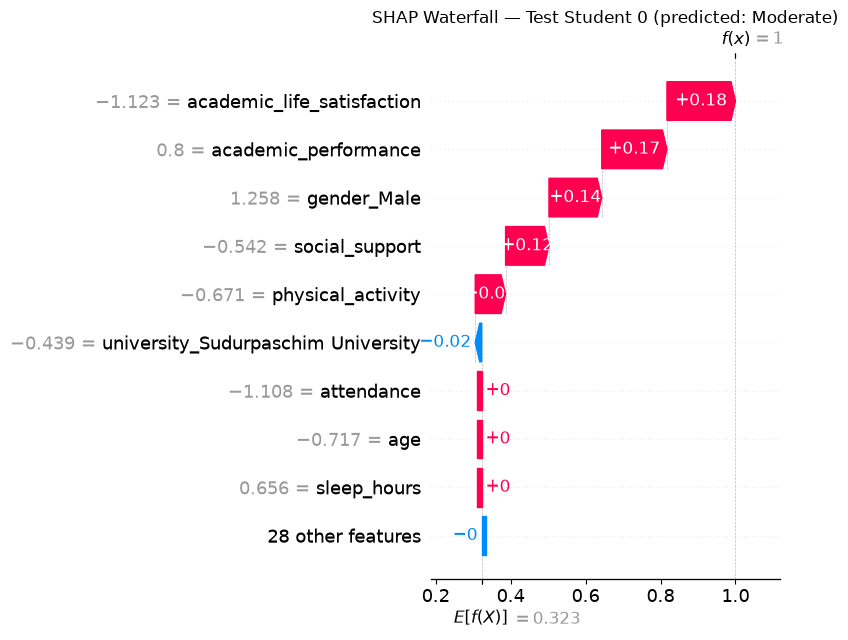

In [8]:
# Step 6b: SHAP waterfall plots for individual students.

# SHAP local plots require a single row's values and the class index
# For multiclass, we plot against the PREDICTED class

# We use the SHAP explainer on the test rows only
# Recompute SHAP values on test set for local plots
shap_values_test = explainer.shap_values(X_test_scaled_df)
if isinstance(shap_values_test, list):
    pass
elif shap_values_test.ndim == 3:
    shap_values_test = [shap_values_test[:, :, i] for i in range(shap_values_test.shape[2])]

# Helper: get class index from class name
def class_idx(name):
    return list(model.classes_).index(name)

# ---- Student at test index 2 (correct: High) ----
idx = 2
pred_class = y_pred_test[idx]
class_i = class_idx(pred_class)

print(f"Student at test index {idx}: True={y_test.iloc[idx]}, Pred={pred_class}")

plt.figure(figsize=(10, 6))
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_test[class_i][idx],
        base_values=explainer.expected_value[class_i],
        data=X_test_scaled_df.iloc[idx].values,
        feature_names=X.columns.tolist(),
    ),
    max_display=10,
    show=False,
)
plt.title(f"SHAP Waterfall — Test Student {idx} (predicted: {pred_class})")
plt.tight_layout()
plt.savefig(f"../figures/shap_waterfall_student_{idx}.png", dpi=150, bbox_inches="tight")
print(f"Saved: ../figures/shap_waterfall_student_{idx}.png")
plt.show()
plt.close()


# ---- Student at test index 0 (wrong: truly Low, predicted Moderate) ----
idx = 0
pred_class = y_pred_test[idx]
class_i = class_idx(pred_class)

print(f"\nStudent at test index {idx}: True={y_test.iloc[idx]}, Pred={pred_class}")

plt.figure(figsize=(10, 6))
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_test[class_i][idx],
        base_values=explainer.expected_value[class_i],
        data=X_test_scaled_df.iloc[idx].values,
        feature_names=X.columns.tolist(),
    ),
    max_display=10,
    show=False,
)
plt.title(f"SHAP Waterfall — Test Student {idx} (predicted: {pred_class})")
plt.tight_layout()
plt.savefig(f"../figures/shap_waterfall_student_{idx}.png", dpi=150, bbox_inches="tight")
print(f"Saved: ../figures/shap_waterfall_student_{idx}.png")
plt.show()
plt.close()

## Summary

**What SHAP revealed:**

1. The Decision Tree relied primarily on 5 features:
   - `academic_life_satisfaction`
   - `social_support`
   - `gender_Male`
   - `academic_performance`
   - `cgpa`

2. The remaining 30 features received zero SHAP importance — the tree
   did not use them to make any decision.

3. The **directions** of several effects are inconsistent with psychological
   theory (e.g., high academic life satisfaction predicting higher stress).
   This is strong evidence of overfitting to a small sample.

4. Local waterfalls show individual predictions are driven by a handful
   of features with confidence that reflects small-leaf-node statistics,
   not robust decision boundaries.

**What we can claim:**
- The pipeline for computing SHAP values is correct and reproducible.
- The technique can be applied to the same data once a larger sample is
  collected.

**What we cannot claim:**
- That these 5 features are the true drivers of academic stress.
- Any causal relationship between features and stress.
- That the model's learned patterns generalize beyond this dataset.

**Next steps:**
- Collect 300+ responses and re-run the entire pipeline.
- At n=300+, SHAP values become statistically meaningful and rank
  features reliably.
- Consider comparing SHAP rankings across multiple models — stability
  across models is a stronger sign of a genuine signal.